In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.8 MB/s eta 0:00:00


In [2]:
import cv2
import easyocr
from ultralytics import YOLO
import matplotlib.pyplot as plt
import random
import os
import glob

import warnings
warnings.filterwarnings("ignore")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
data_yaml = f"""
train: {"/kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/images/train"}
val: {"/kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/images/val"}

nc: {1}  # Number of classes
names: {["license_plate"]}  # Class names
"""
path = "/kaggle/working/data.yaml"
with open(path, "w") as f:
    f.write(data_yaml)

In [4]:
model = YOLO('yolo26n.pt')
results = model.train(data = "/kaggle/working/data.yaml", epochs = 50, imgsz = 640)

Ultralytics 8.4.155 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=False


0: 384x640 1 license_plate, 10.5ms
Speed: 2.4ms preprocess, 10.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)
Img: video6_1030.jpg | Plate: NHO2 DS9365 | Conf: 0.61

0: 640x640 1 license_plate, 68.6ms
Speed: 3.9ms preprocess, 68.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Img: video9_110.jpg | Plate: NHO IDT1917 | Conf: 0.70

0: 640x640 1 license_plate, 10.5ms
Speed: 2.8ms preprocess, 10.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Img: video5_340.jpg | Plate: MH.O3.CS.8286 | Conf: 0.70

0: 640x640 1 license_plate, 11.7ms
Speed: 2.0ms preprocess, 11.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Img: video6_220.jpg | Plate: P9[t460774 | Conf: 0.23

0: 608x640 1 license_plate, 64.2ms
Speed: 2.3ms preprocess, 64.2ms inference, 1.4ms postprocess per image at shape (1, 3, 608, 640)
Img: video8_1090.jpg | Plate: Hhl2442025 | Conf: 0.02

0: 640x640 1 license_plate, 12.6ms
Speed: 2.9ms preprocess, 12

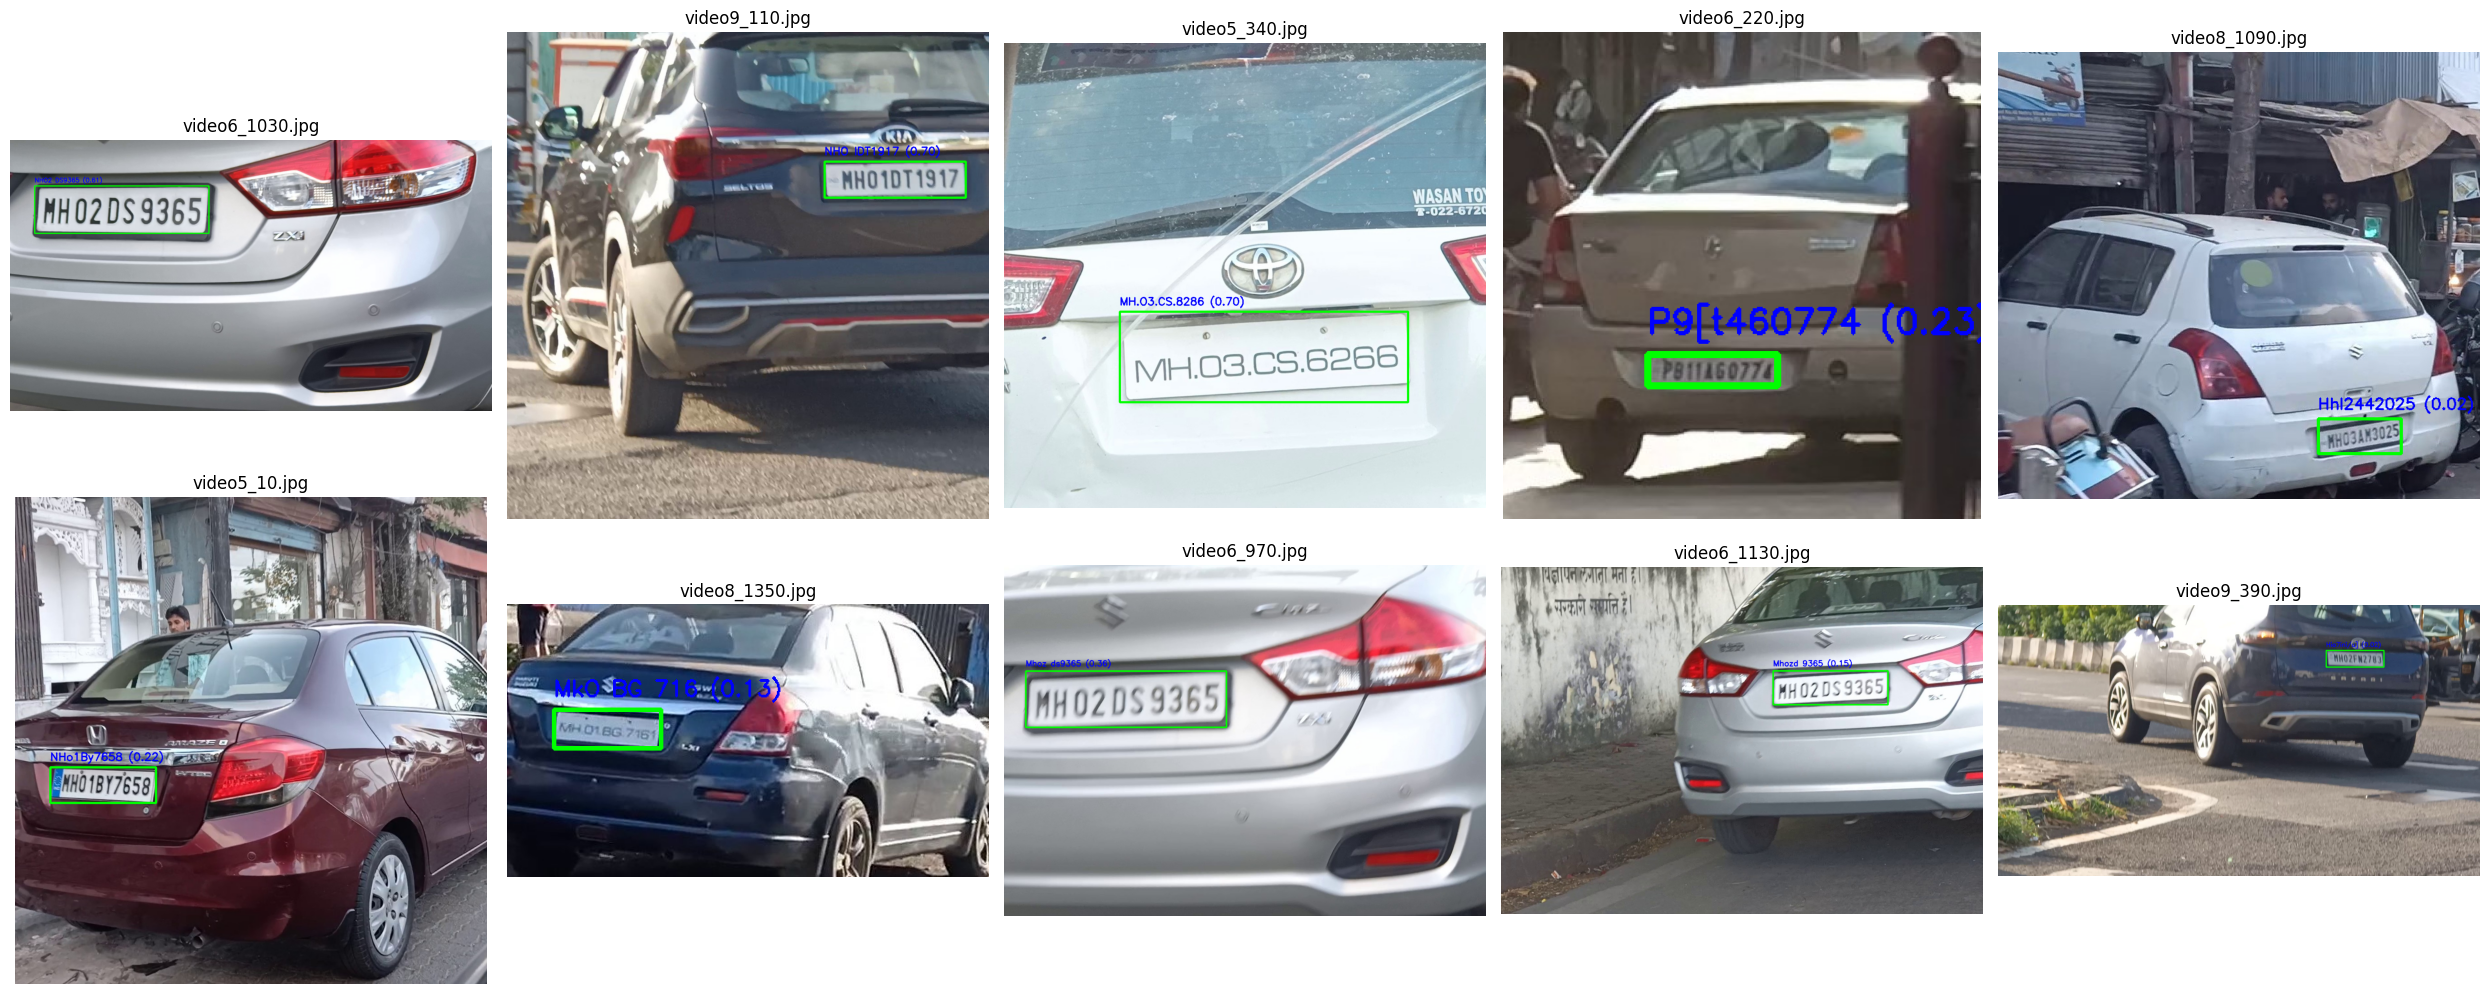

In [5]:
model_path = '/kaggle/working/runs/detect/train/weights/best.pt'
yolo_model = YOLO(model_path) 

reader = easyocr.Reader(['en'], gpu=True) 

val_images_path = "/kaggle/input/datasets/ronakgohil/license-plate-dataset/archive/images/val"

image_files = glob.glob(os.path.join(val_images_path, '*.jpg')) + \
              glob.glob(os.path.join(val_images_path, '*.jpeg')) + \
              glob.glob(os.path.join(val_images_path, '*.png'))

random_images = random.sample(image_files, 10)

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten() 

for idx, img_path in enumerate(random_images):
    image = cv2.imread(img_path)
    
    if image is None:
        axes[idx].set_title("Image Load Error", color='red')
        axes[idx].axis('off')
        continue

    results = yolo_model(image)
    
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            
            cropped_plate = image[y1:y2, x1:x2]
            
            gray_plate = cv2.cvtColor(cropped_plate, cv2.COLOR_BGR2GRAY)
            bfilter = cv2.bilateralFilter(gray_plate, 11, 17, 17) 
            
            ocr_results = reader.readtext(bfilter)
            
            for (bbox, text, prob) in ocr_results:
                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 3)
                cv2.putText(image, f"{text} ({prob:.2f})", (x1, max(y1 - 15, 20)), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
                
                print(f"Img: {os.path.basename(img_path)} | Plate: {text} | Conf: {prob:.2f}")

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(image_rgb)
    axes[idx].set_title(os.path.basename(img_path))
    axes[idx].axis('off')

plt.tight_layout()
plt.show()